In [1]:
import os
import sys

sys.path.append("../")

import matplotlib.pyplot as plt
import numpy as np

In [2]:
from python.decision_maker import DecisionMaker, HiddenDecisionMakers
from python.query import BridgeQuery, SquaredQuery
from python.identify import UTAsIdentification

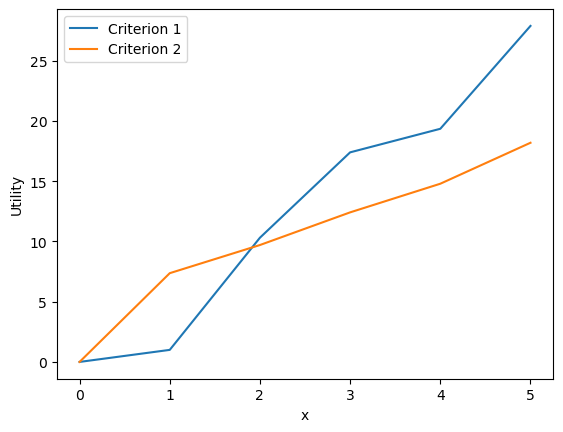

In [3]:
single_dm = DecisionMaker(2, 5)
single_dm.plot_decision_function()

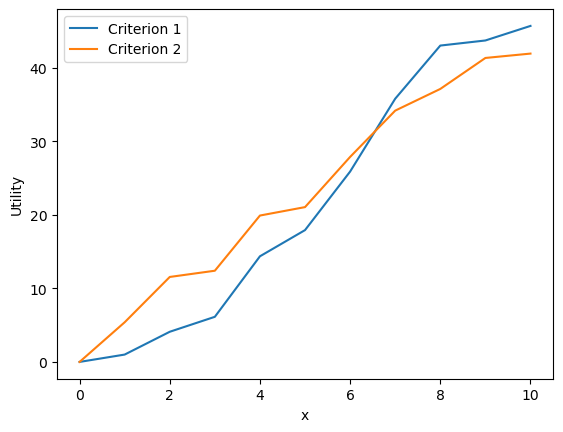

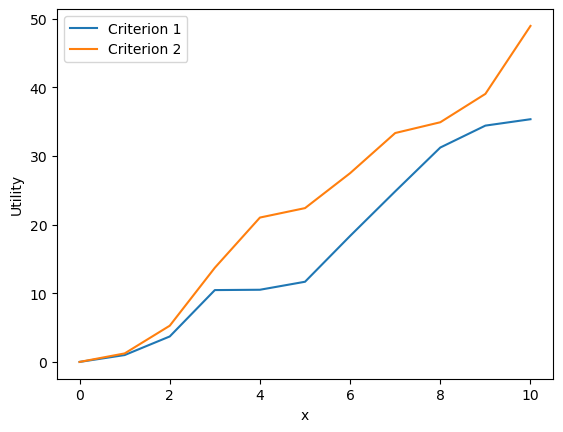

In [4]:
hdm = HiddenDecisionMakers(n_dms=2, n_criteria=2, n_pieces=10)
hdm.dms[0].plot_decision_function()
hdm.dms[1].plot_decision_function()

In [5]:
hdm.dms[1].slopes, hdm.dms[0].slopes

(array([[1.        , 2.70838389, 6.75311793, 0.04843074, 1.16489899,
         6.67239056, 6.48898815, 6.38318542, 3.19318816, 0.92999622],
        [1.23826174, 4.03560122, 8.44321565, 7.30618324, 1.37527439,
         5.08927303, 5.84500267, 1.5681675 , 4.13207138, 9.89648412]]),
 array([[1.        , 3.10241599, 2.035148  , 8.23251665, 3.56387709,
         7.96361692, 9.91242826, 7.22904918, 0.69215738, 1.98037527],
        [5.39383374, 6.16582195, 0.8475376 , 7.50663925, 1.14805564,
         6.82805916, 6.2986879 , 2.95082615, 4.21369667, 0.59428588]]))

In [6]:
identif = UTAsIdentification(2, 10)
identif.identify_hdms(hdms=hdm)

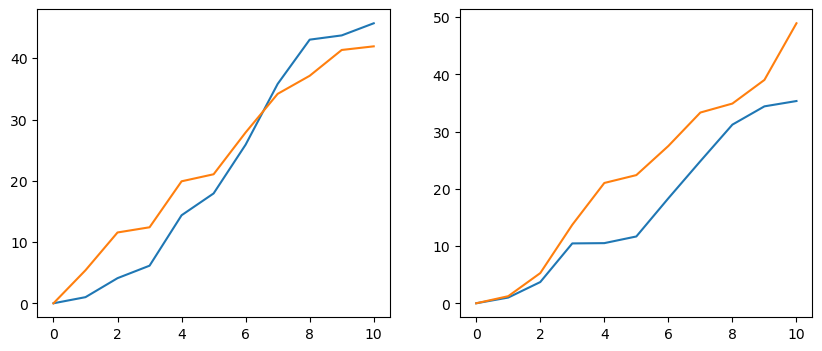

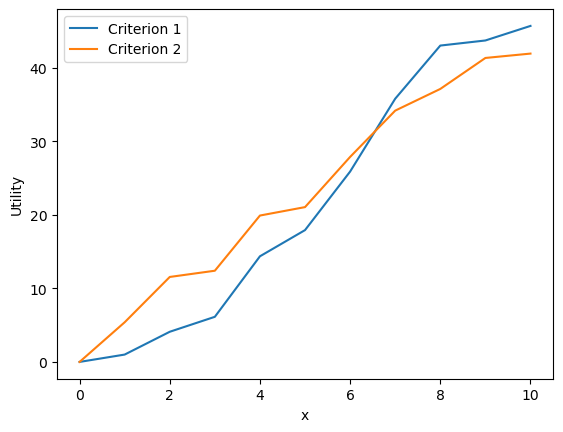

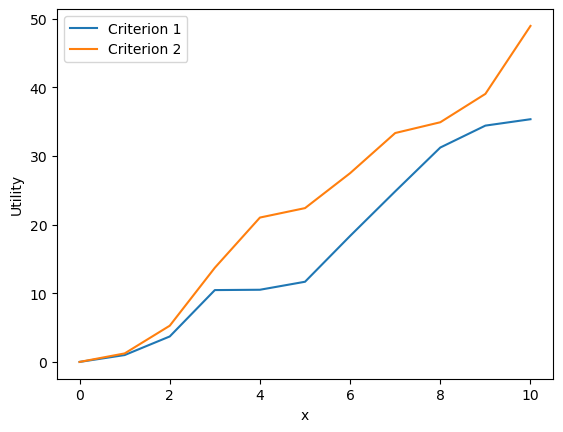

In [7]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
alpha_0 = [0]
for i in identif.slopes["alpha"][0]:
    alpha_0.append(i + alpha_0[-1])
alpha_1 = [0]
for i in identif.slopes["alpha"][1]:
    alpha_1.append(i + alpha_1[-1])
plt.plot(alpha_0)
plt.plot(alpha_1)

plt.subplot(1, 2, 2)
beta_0 = [0]
for i in identif.slopes["beta"][0]:
    beta_0.append(i + beta_0[-1])
beta_1 = [0]
for i in identif.slopes["beta"][1]:
    beta_1.append(i + beta_1[-1])
plt.plot(beta_0)
plt.plot(beta_1)
plt.show()

hdm.dms[0].plot_decision_function()
hdm.dms[1].plot_decision_function()

In [8]:
np.array(identif.slopes["alpha"])

array([[1.        , 3.10241599, 2.035148  , 8.23251665, 3.56387709,
        7.96361692, 9.91242826, 7.22904918, 0.69215738, 1.98037527],
       [5.39383374, 6.16582195, 0.8475376 , 7.50663925, 1.14805564,
        6.82805916, 6.2986879 , 2.95082615, 4.21369667, 0.59428588]])

In [9]:
hdm.dms[1].slopes

array([[1.        , 2.70838389, 6.75311793, 0.04843074, 1.16489899,
        6.67239056, 6.48898815, 6.38318542, 3.19318816, 0.92999622],
       [1.23826174, 4.03560122, 8.44321565, 7.30618324, 1.37527439,
        5.08927303, 5.84500267, 1.5681675 , 4.13207138, 9.89648412]])

In [10]:
a = np.sum((np.array(identif.slopes["alpha"]) - hdm.dms[0].slopes)**2) + np.sum((np.array(identif.slopes["beta"]) - hdm.dms[1].slopes)**2)
b = np.sum((np.array(identif.slopes["alpha"]) - hdm.dms[1].slopes)**2) + np.sum((np.array(identif.slopes["beta"]) - hdm.dms[0].slopes)**2)

In [11]:
np.sum(hdm.get_total_n_answers())

np.int64(128)

In [19]:
import tqdm
n_queries = []
errors = []

for _ in tqdm.trange(1000):
    hdm = HiddenDecisionMakers(n_dms=2, n_criteria=2, n_pieces=10)
    identif = UTAsIdentification(2, 10)
    identif.identify_hdms(hdms=hdm)
    n_queries.append(np.sum(hdm.get_total_n_answers()))
    a = np.sum((np.array(identif.slopes["alpha"]) - hdm.dms[0].slopes)**2) + np.sum((np.array(identif.slopes["beta"]) - hdm.dms[1].slopes)**2)
    b = np.sum((np.array(identif.slopes["alpha"]) - hdm.dms[1].slopes)**2) + np.sum((np.array(identif.slopes["beta"]) - hdm.dms[0].slopes)**2)
    errors.append(np.min([a, b]))
    if np.min([a, b]) > 0.1:
        print("Error too high")

  0%|          | 1/1000 [00:00<01:44,  9.60it/s]/Users/vincent.auriau/Python/eliciting-discrete-mixtures-of-UTAs/notebooks/../python/identify.py:112: RuntimeWarning: invalid value encountered in scalar divide
  possible_slopes = [((I1[1][1] - I1[0][1]) / (I1[0][0] - I1[1][0])) * self.slopes["alpha"][opposite_criterion][1],
/Users/vincent.auriau/Python/eliciting-discrete-mixtures-of-UTAs/notebooks/../python/identify.py:113: RuntimeWarning: invalid value encountered in scalar divide
  ((I2[1][1] - I2[0][1]) / (I2[0][0] - I2[1][0]))* self.slopes["beta"][opposite_criterion][1]]
/Users/vincent.auriau/Python/eliciting-discrete-mixtures-of-UTAs/notebooks/../python/identify.py:114: RuntimeWarning: invalid value encountered in scalar divide
  other_possible_slopes = [((I1[1][1] - I1[0][1]) / (I1[0][0] - I1[1][0])) * self.slopes["beta"][opposite_criterion][1],
/Users/vincent.auriau/Python/eliciting-discrete-mixtures-of-UTAs/notebooks/../python/identify.py:115: RuntimeWarning: invalid value encou

Error too high


 11%|█         | 109/1000 [00:02<00:16, 54.31it/s]

Error too high


 14%|█▍        | 139/1000 [00:02<00:15, 55.93it/s]

...

Error too high
Error too high


 98%|█████████▊| 979/1000 [00:18<00:00, 53.96it/s]

Error too high


100%|██████████| 1000/1000 [00:18<00:00, 54.37it/s]

Error too high


In [20]:
hdm.get_total_n_answers()

[60, 60]

(array([  4.,  12.,  18.,  31.,  65.,  39., 113.,  81., 158.,  96., 180.,
         61.,  91.,  15.,  16.,   5.,   7.,   1.,   4.,   3.]),
 array([106., 109., 112., 115., 118., 121., 124., 127., 130., 133., 136.,
        139., 142., 145., 148., 151., 154., 157., 160., 163., 166.]),
 <BarContainer object of 20 artists>)

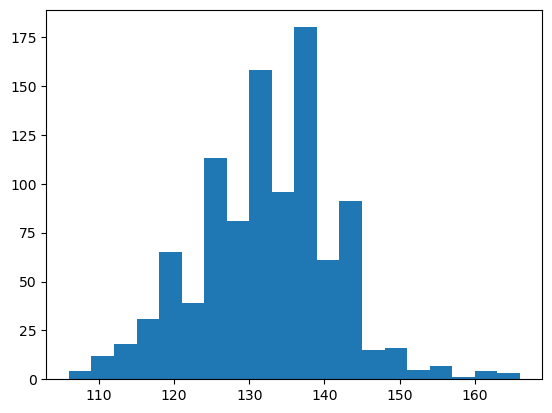

In [21]:
plt.hist(n_queries, bins=20)

(array([905.,   1.,   1.,   3.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   1.,   1.,   0.,   0.,   0.,   1.,   1.]),
 array([4.02910334e-28, 2.02707122e+01, 4.05414244e+01, 6.08121366e+01,
        8.10828488e+01, 1.01353561e+02, 1.21624273e+02, 1.41894985e+02,
        1.62165698e+02, 1.82436410e+02, 2.02707122e+02, 2.22977834e+02,
        2.43248546e+02, 2.63519259e+02, 2.83789971e+02, 3.04060683e+02,
        3.24331395e+02, 3.44602107e+02, 3.64872820e+02, 3.85143532e+02,
        4.05414244e+02]),
 <BarContainer object of 20 artists>)

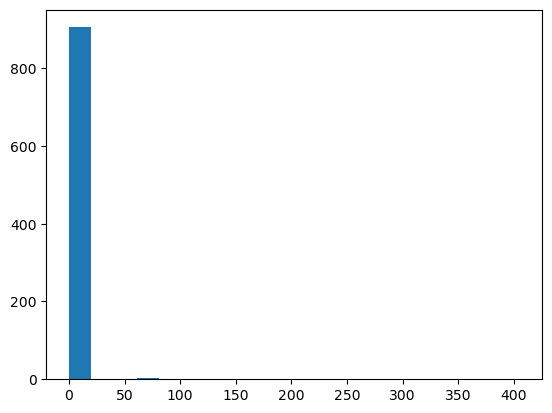

In [16]:
plt.hist(errors, bins=20)

In [17]:
errors

[np.float64(1.0196433956385832e-26),
 np.float64(6.0550094296556905e-25),
 np.float64(1.418770343974274e-26),
 np.float64(4.241151667552001e-25),
 np.float64(6.776063264211766e-27),
 np.float64(1.2752330963350266e-26),
 np.float64(5.13243166291534e-26),
 np.float64(3.780378734073172e-26),
 np.float64(2.2071450674401247e-26),
 np.float64(3.1565751432449736e-26),
 np.float64(8.579008661220831e-24),
 np.float64(6.269817324964421e-25),
 np.float64(nan),
 np.float64(3.3985446673747105e-26),
 np.float64(1.8834595548836922e-25),
 np.float64(5.477694818863991e-26),
 np.float64(3.8408676420761376e-24),
 np.float64(5.022153185855849e-25),
 np.float64(4.698298395612884e-27),
 np.float64(6.535124468899316e-27),
 np.float64(1.0796093044614197e-27),
 np.float64(6.593583135318025e-27),
 np.float64(1.209885831098781e-26),
 np.float64(7.375067536259039e-27),
 np.float64(2.2931577920912387e-27),
 np.float64(3.4452513959396164e-27),
 np.float64(1.888185492299937e-26),
 np.float64(1.9282142513756747e-26),